<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




Valid paired observations: 29399
Pearson correlation: -0.0506


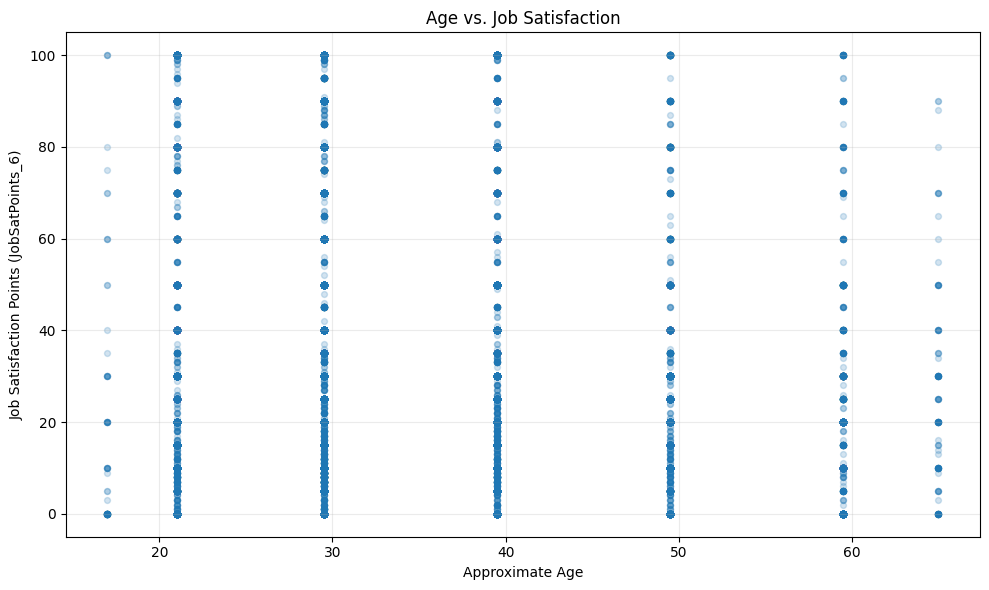

In [3]:
# Task 1.1 - Scatter Plot: Age vs Job Satisfaction

import pandas as pd
import matplotlib.pyplot as plt

# Create a working copy
age_sat = df[["Age", "JobSatPoints_6"]].copy()

# Convert Age categories to approximate numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": None
}

age_sat["AgeNumeric"] = age_sat["Age"].map(age_mapping)

# Convert job satisfaction component to numeric
age_sat["JobSatPoints_6"] = pd.to_numeric(
    age_sat["JobSatPoints_6"],
    errors="coerce"
)

# Keep only valid pairs for this analysis
plot_df = age_sat.dropna(
    subset=["AgeNumeric", "JobSatPoints_6"]
)

print("Valid paired observations:", len(plot_df))

# Correlation for additional validation
correlation = plot_df["AgeNumeric"].corr(
    plot_df["JobSatPoints_6"]
)

print(f"Pearson correlation: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["AgeNumeric"],
    plot_df["JobSatPoints_6"],
    alpha=0.20,
    s=18
)

plt.title("Age vs. Job Satisfaction")
plt.xlabel("Approximate Age")
plt.ylabel("Job Satisfaction Points (JobSatPoints_6)")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Analysis – Age vs. Job Satisfaction

The scatter plot shows the relationship between respondents' approximate age and `JobSatPoints_6`.

The observations form vertical clusters because `Age` was originally recorded as age ranges and then converted into representative numeric values. Therefore, the x-axis represents approximate age groups rather than exact individual ages.

Across all age groups, `JobSatPoints_6` values are widely dispersed, ranging from very low to very high scores. There is substantial overlap between age groups, and no clear increasing or decreasing pattern is visually apparent.

This suggests that **age alone does not appear to have a strong relationship with this job satisfaction component**. Respondents of similar ages can report very different satisfaction-point values, while respondents from different age groups may report similar scores.

The visualization therefore supports the hypothesis that job satisfaction is likely influenced by several factors beyond age, such as compensation, employment conditions, professional role, workload, career development, or work environment.

Because age was transformed from categorical ranges into approximate numerical values, the scatter plot should be interpreted as a comparison between age groups rather than as an analysis of exact ages. In addition, the visualization identifies association patterns only and does not establish causation.

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


Valid paired observations: 16185
Pearson correlation: -0.0085
99th percentile compensation: $368,847.84


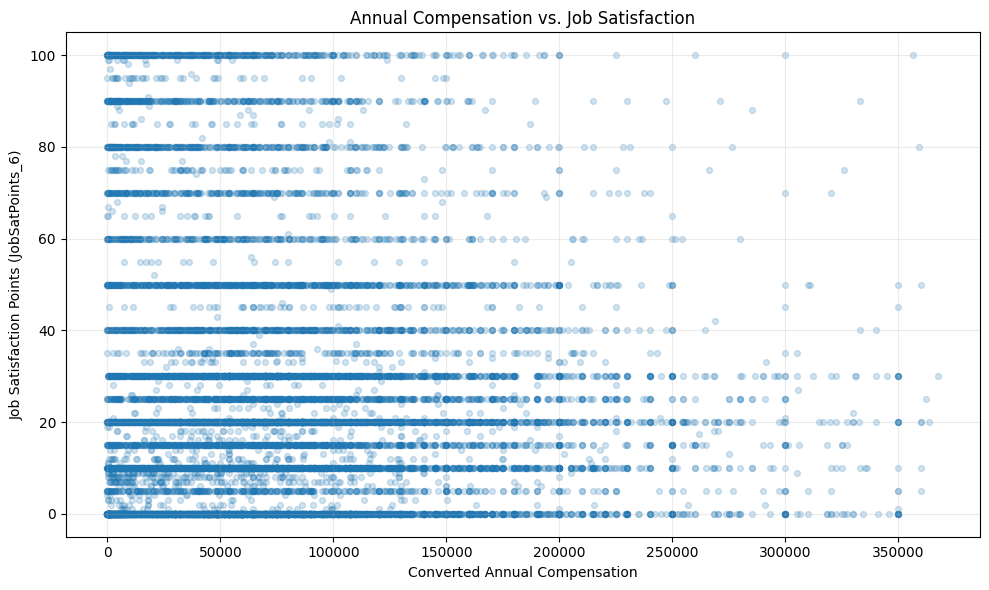

In [4]:
# Task 1.2 - Compensation vs. Job Satisfaction

comp_sat = df[
    ["ConvertedCompYearly", "JobSatPoints_6"]
].copy()

# Convert both variables to numeric
comp_sat["ConvertedCompYearly"] = pd.to_numeric(
    comp_sat["ConvertedCompYearly"],
    errors="coerce"
)

comp_sat["JobSatPoints_6"] = pd.to_numeric(
    comp_sat["JobSatPoints_6"],
    errors="coerce"
)

# Keep valid paired observations
plot_df = comp_sat.dropna(
    subset=["ConvertedCompYearly", "JobSatPoints_6"]
)

print("Valid paired observations:", len(plot_df))

# Pearson correlation
correlation = plot_df["ConvertedCompYearly"].corr(
    plot_df["JobSatPoints_6"]
)

print(f"Pearson correlation: {correlation:.4f}")

# Limit only the visualization
visual_limit = plot_df["ConvertedCompYearly"].quantile(0.99)

print(f"99th percentile compensation: ${visual_limit:,.2f}")

plot_visual = plot_df[
    plot_df["ConvertedCompYearly"] <= visual_limit
]

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_visual["ConvertedCompYearly"],
    plot_visual["JobSatPoints_6"],
    alpha=0.20,
    s=18
)

plt.title("Annual Compensation vs. Job Satisfaction")
plt.xlabel("Converted Annual Compensation")
plt.ylabel("Job Satisfaction Points (JobSatPoints_6)")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Analysis – Annual Compensation vs. Job Satisfaction

The scatter plot shows the relationship between `ConvertedCompYearly` and `JobSatPoints_6`.

The observations are widely dispersed across nearly all compensation levels. Respondents with similar annual compensation report very different job satisfaction scores, ranging from very low values to scores close to 100.

There is no clear upward or downward pattern in the distribution of the points. This suggests that **annual compensation alone does not appear to have a strong relationship with this component of job satisfaction**.

The horizontal bands visible in the chart occur because `JobSatPoints_6` contains repeated discrete values rather than continuously varying observations. This produces groups of respondents with the same satisfaction score but very different compensation levels.

Most observations are concentrated below approximately **$200,000–$250,000 per year**, while higher compensation values are less frequent. Even among these higher-paid respondents, satisfaction remains widely distributed.

For visualization purposes, compensation values above the 99th percentile were excluded from the displayed scatter plot to prevent extreme observations from compressing the main distribution. However, this visual adjustment does not modify the original dataset or the correlation calculation.

Overall, the plot suggests that compensation may contribute to job satisfaction, but it is unlikely to explain it by itself. Other factors such as workload, professional role, career progression, management, work environment, and employment conditions may also influence respondents' satisfaction.

The scatter plot demonstrates association patterns only and does not establish a causal relationship between compensation and job satisfaction.

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


Valid observations: 29399
Pearson correlation: -0.0506


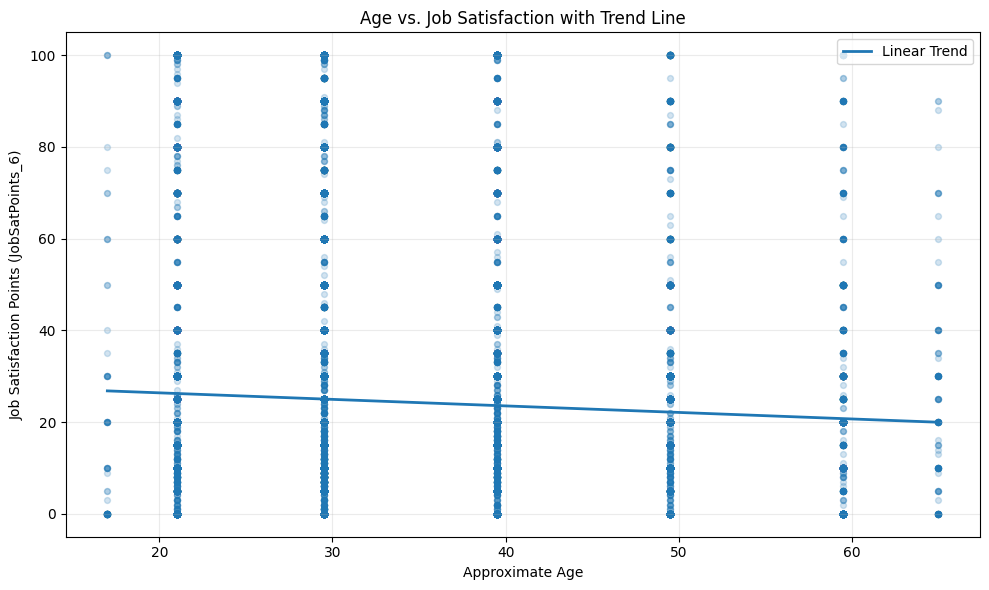

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": np.nan
}

age_sat = df[["Age", "JobSatPoints_6"]].copy()

age_sat["AgeNumeric"] = age_sat["Age"].map(age_mapping)

age_sat["JobSatPoints_6"] = pd.to_numeric(
    age_sat["JobSatPoints_6"],
    errors="coerce"
)

plot_df = age_sat.dropna(
    subset=["AgeNumeric", "JobSatPoints_6"]
)

# Pearson correlation
corr = plot_df["AgeNumeric"].corr(
    plot_df["JobSatPoints_6"]
)

print("Valid observations:", len(plot_df))
print(f"Pearson correlation: {corr:.4f}")

# Linear regression
slope, intercept = np.polyfit(
    plot_df["AgeNumeric"],
    plot_df["JobSatPoints_6"],
    1
)

x_line = np.linspace(
    plot_df["AgeNumeric"].min(),
    plot_df["AgeNumeric"].max(),
    100
)

y_line = slope * x_line + intercept

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["AgeNumeric"],
    plot_df["JobSatPoints_6"],
    alpha=0.20,
    s=18
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear Trend"
)

plt.title("Age vs. Job Satisfaction with Trend Line")
plt.xlabel("Approximate Age")
plt.ylabel("Job Satisfaction Points (JobSatPoints_6)")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


Valid observations: 51487
Pearson correlation: 0.8329


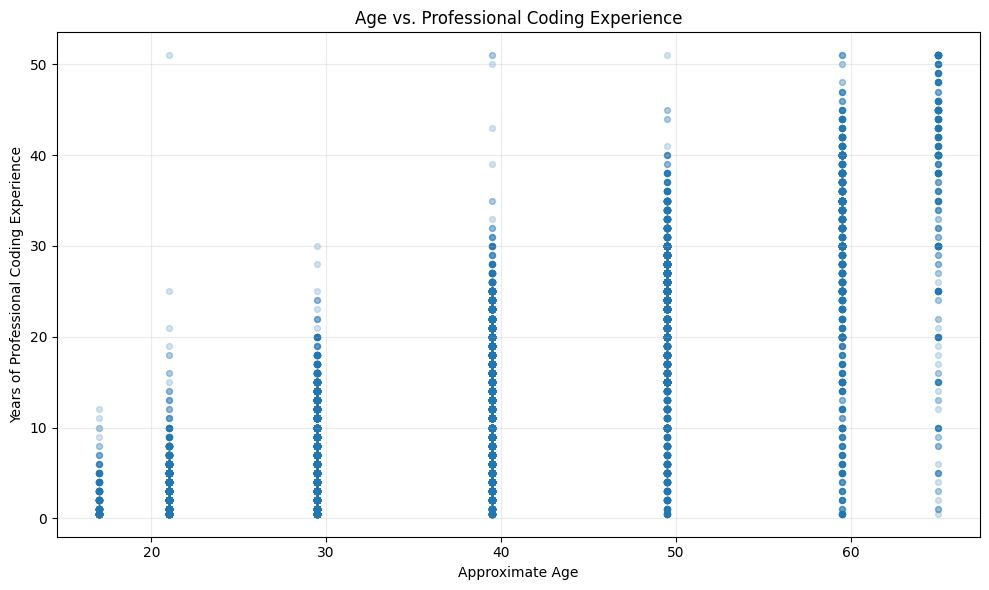

In [6]:
age_exp = df[
    ["Age", "YearsCodePro"]
].copy()

# Convert Age
age_exp["AgeNumeric"] = age_exp["Age"].map(age_mapping)

# Convert YearsCodePro
age_exp["YearsCodeProNumeric"] = (
    age_exp["YearsCodePro"]
    .replace({
        "Less than 1 year": 0.5,
        "More than 50 years": 51
    })
)

age_exp["YearsCodeProNumeric"] = pd.to_numeric(
    age_exp["YearsCodeProNumeric"],
    errors="coerce"
)

plot_df = age_exp.dropna(
    subset=["AgeNumeric", "YearsCodeProNumeric"]
)

corr = plot_df["AgeNumeric"].corr(
    plot_df["YearsCodeProNumeric"]
)

print("Valid observations:", len(plot_df))
print(f"Pearson correlation: {corr:.4f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["AgeNumeric"],
    plot_df["YearsCodeProNumeric"],
    alpha=0.20,
    s=18
)

plt.title("Age vs. Professional Coding Experience")
plt.xlabel("Approximate Age")
plt.ylabel("Years of Professional Coding Experience")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


Valid observations: 16177
99th percentile used only for visualization: $369,433.76


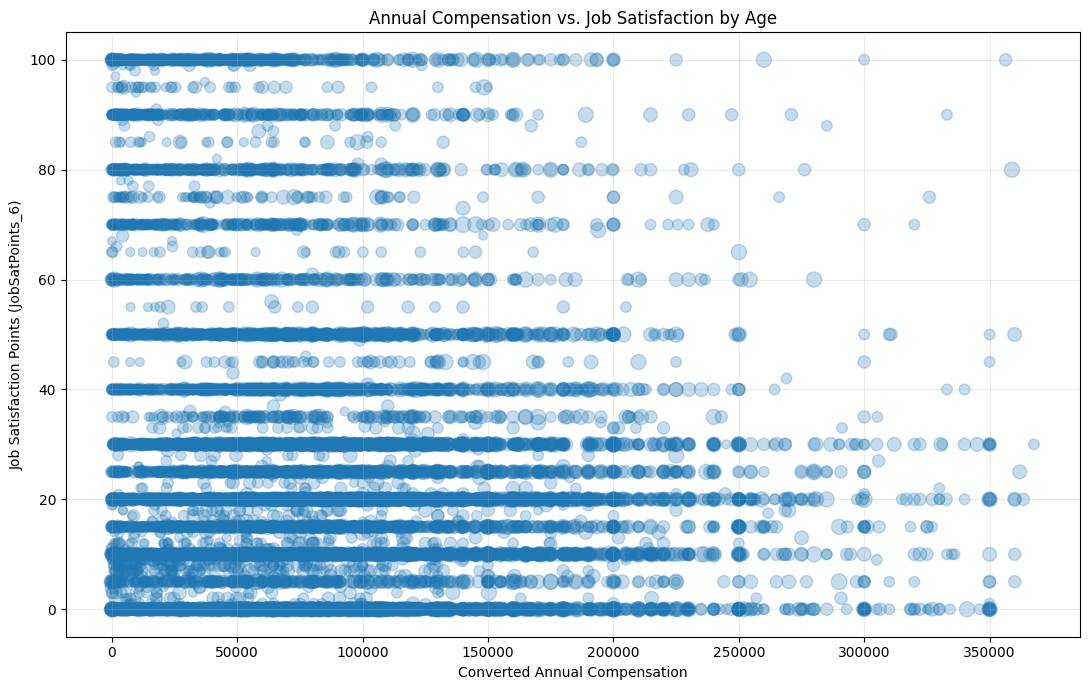

In [7]:
bubble_df = df[
    ["Age", "ConvertedCompYearly", "JobSatPoints_6"]
].copy()

# Convert Age
bubble_df["AgeNumeric"] = bubble_df["Age"].map(age_mapping)

# Convert compensation
bubble_df["ConvertedCompYearly"] = pd.to_numeric(
    bubble_df["ConvertedCompYearly"],
    errors="coerce"
)

# Convert satisfaction
bubble_df["JobSatPoints_6"] = pd.to_numeric(
    bubble_df["JobSatPoints_6"],
    errors="coerce"
)

bubble_df = bubble_df.dropna(
    subset=[
        "AgeNumeric",
        "ConvertedCompYearly",
        "JobSatPoints_6"
    ]
)

print("Valid observations:", len(bubble_df))

# Visual limit only — preserve original data
visual_limit = bubble_df[
    "ConvertedCompYearly"
].quantile(0.99)

plot_df = bubble_df[
    bubble_df["ConvertedCompYearly"] <= visual_limit
].copy()

print(
    f"99th percentile used only for visualization: "
    f"${visual_limit:,.2f}"
)

# Bubble size based on age
bubble_sizes = plot_df["AgeNumeric"] * 2

plt.figure(figsize=(11, 7))

plt.scatter(
    plot_df["ConvertedCompYearly"],
    plot_df["JobSatPoints_6"],
    s=bubble_sizes,
    alpha=0.25
)

plt.title(
    "Annual Compensation vs. Job Satisfaction by Age"
)
plt.xlabel("Converted Annual Compensation")
plt.ylabel("Job Satisfaction Points (JobSatPoints_6)")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [ ]:
## Write your code here

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [ ]:
## Write your code here

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [ ]:
## Write your code here

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->
